In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


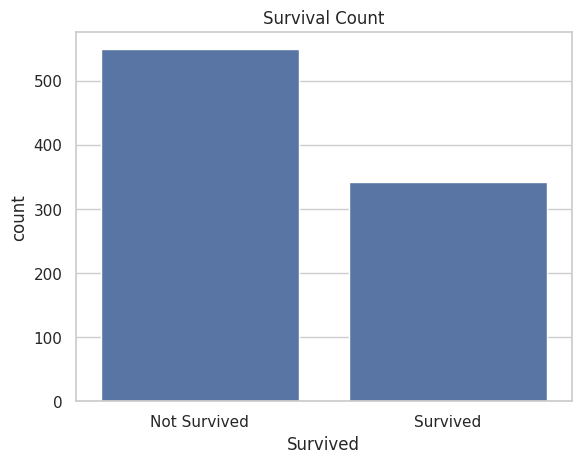

In [6]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xticks([0,1], ["Not Survived", "Survived"])
plt.show()

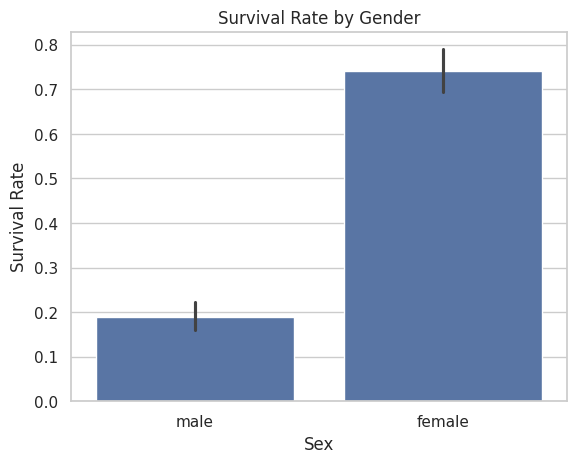

,Survived
Sex,
female,0.742038
male,0.188908


In [7]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

df.groupby("Sex")["Survived"].mean()

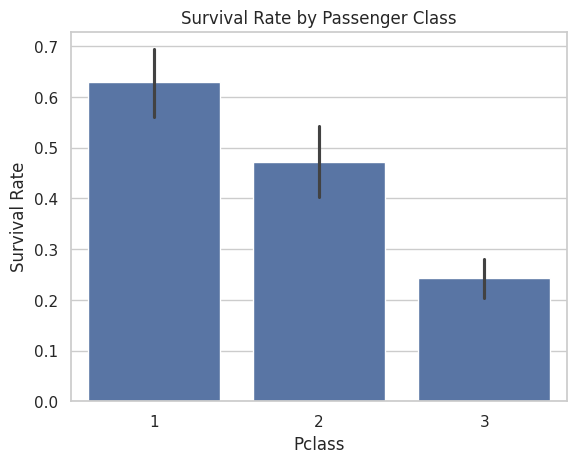

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [8]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

df.groupby("Pclass")["Survived"].mean()

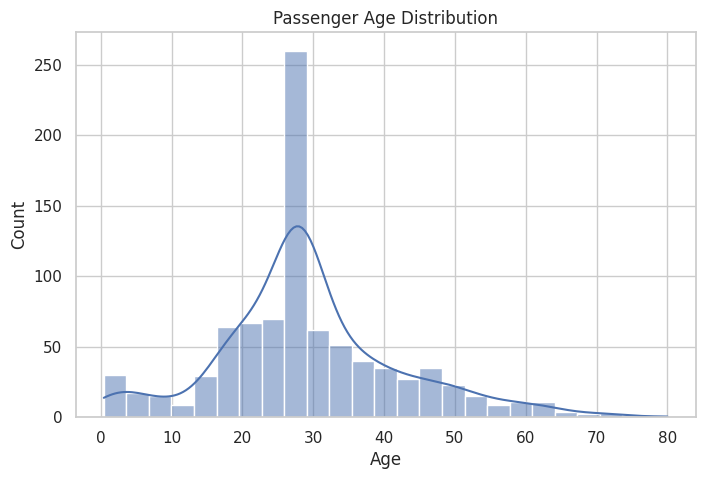

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=25, kde=True)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.show()

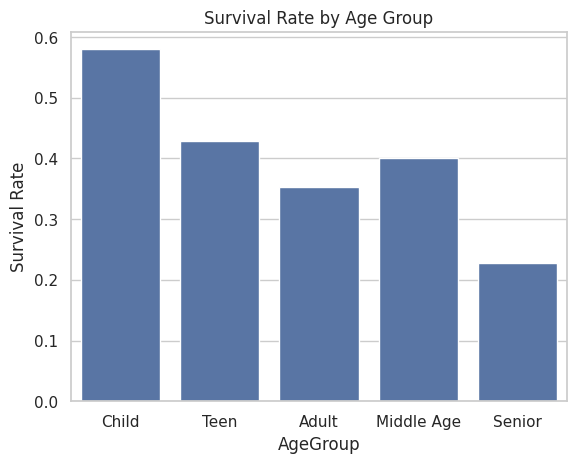

,AgeGroup,Survived
0,Child,0.579710
1,Teen,0.428571
2,Adult,0.353271
3,Middle Age,0.400000
4,Senior,0.227273


In [10]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Adult", "Middle Age", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_survival = df.groupby("AgeGroup")["Survived"].mean().reset_index()

sns.barplot(x="AgeGroup", y="Survived", data=age_survival)
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.show()

age_survival

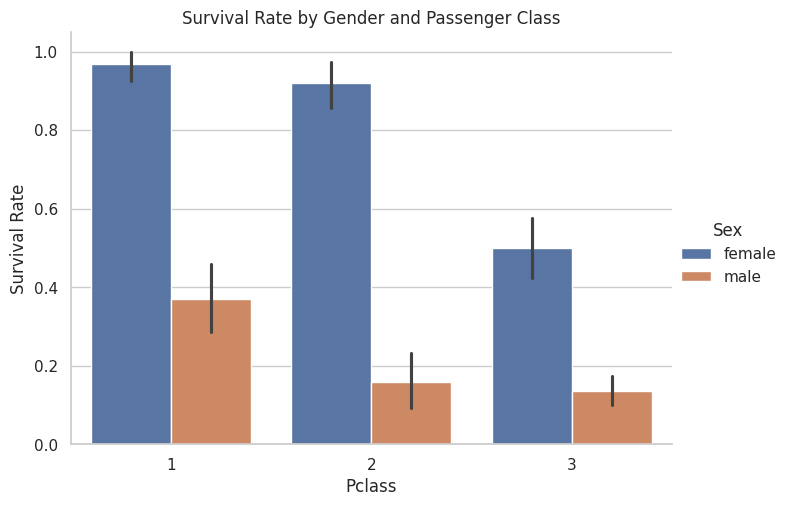

In [11]:
sns.catplot(
    x="Pclass",
    y="Survived",
    hue="Sex",
    kind="bar",
    data=df,
    height=5,
    aspect=1.4
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

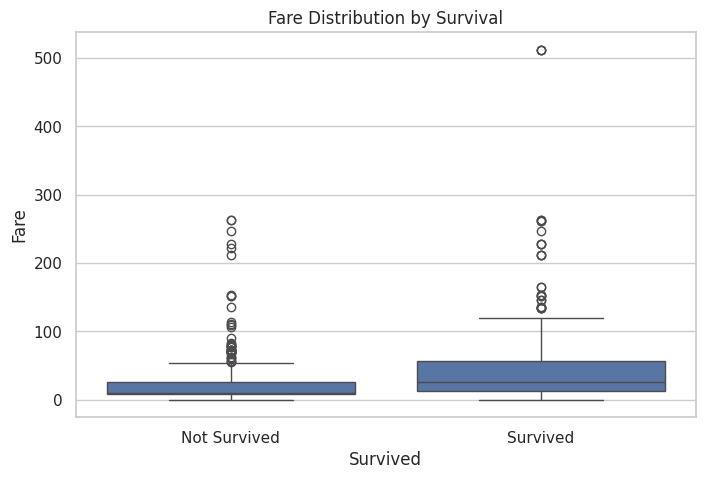

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare Distribution by Survival")
plt.xticks([0,1], ["Not Survived", "Survived"])
plt.show()

In [13]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = 0
df.loc[df["FamilySize"] == 1, "IsAlone"] = 1

df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df[["Name", "Title", "FamilySize", "IsAlone"]].head()

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


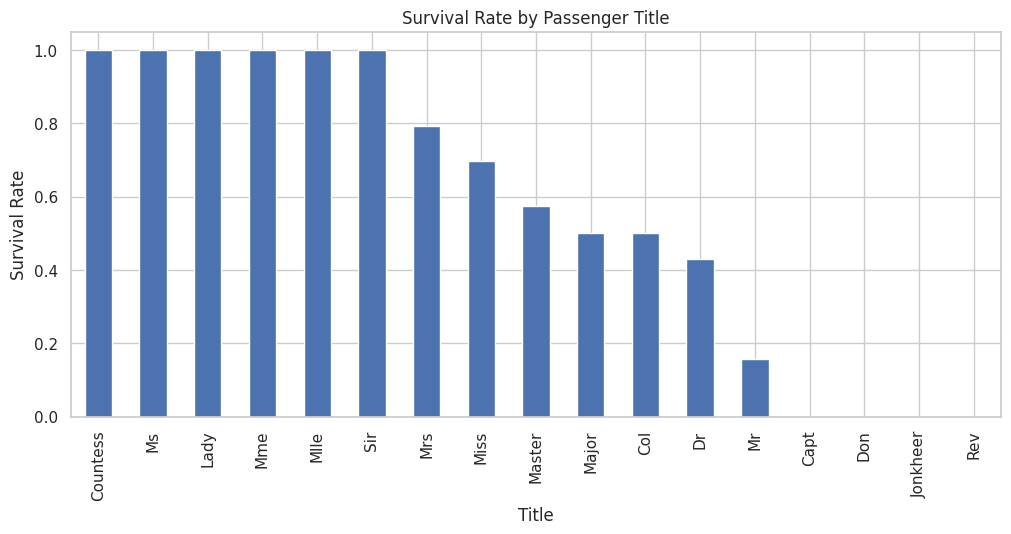

In [14]:
title_survival = df.groupby("Title")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
title_survival.plot(kind="bar")
plt.title("Survival Rate by Passenger Title")
plt.ylabel("Survival Rate")
plt.show()

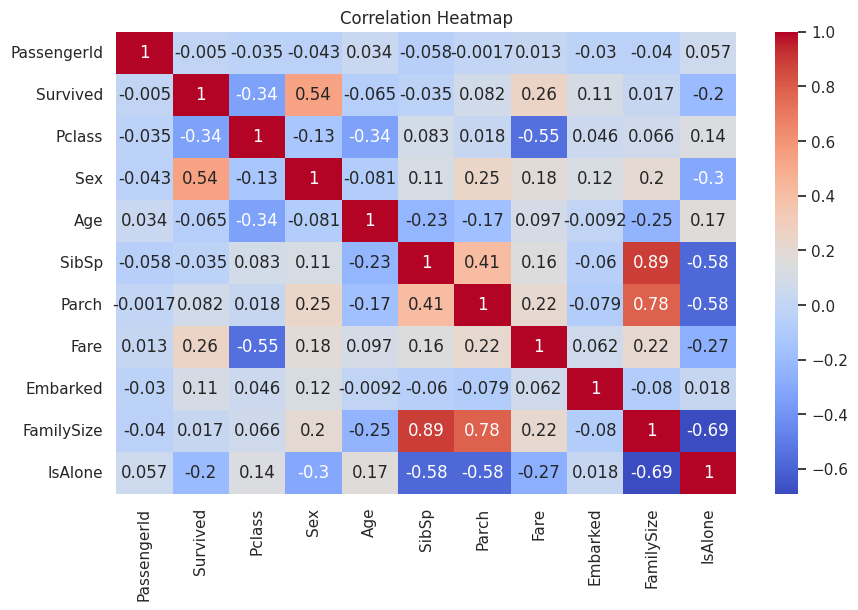

In [15]:
df_ml = df.copy()

df_ml["Sex"] = df_ml["Sex"].map({"male": 0, "female": 1})
df_ml["Embarked"] = df_ml["Embarked"].map({"S": 0, "C": 1, "Q": 2})

numeric_df = df_ml.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "IsAlone", "Embarked"]

X = df_ml[features]
y = df_ml["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8100558659217877

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.83      0.68      0.75        74

    accuracy                           0.81       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



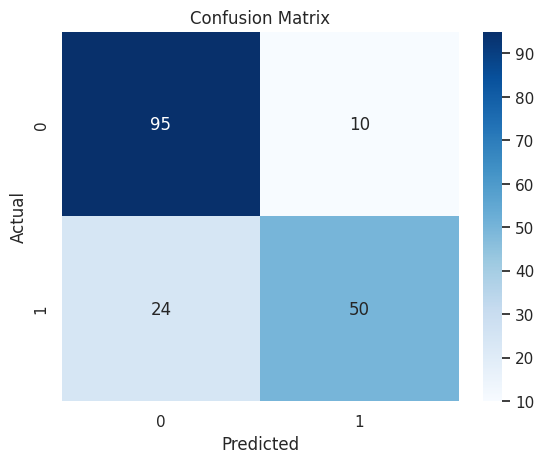

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
1,Sex,0.416842
3,Fare,0.192723
2,Age,0.139002
0,Pclass,0.131905
4,FamilySize,0.072099
6,Embarked,0.029332
5,IsAlone,0.018097


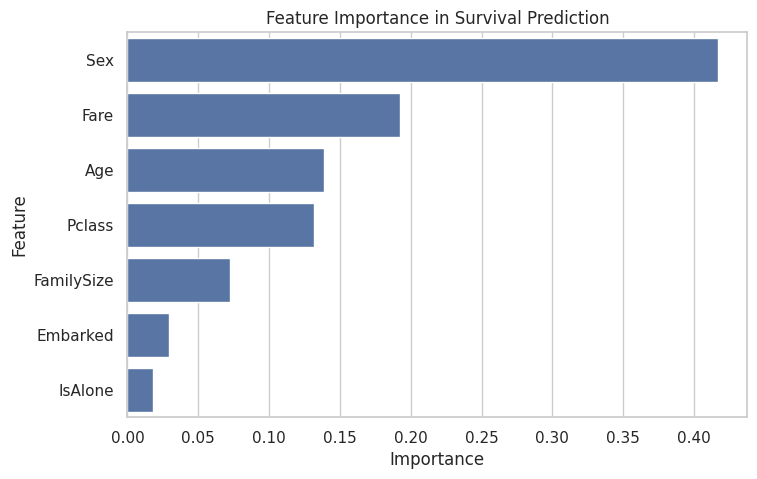

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance in Survival Prediction")
plt.show()

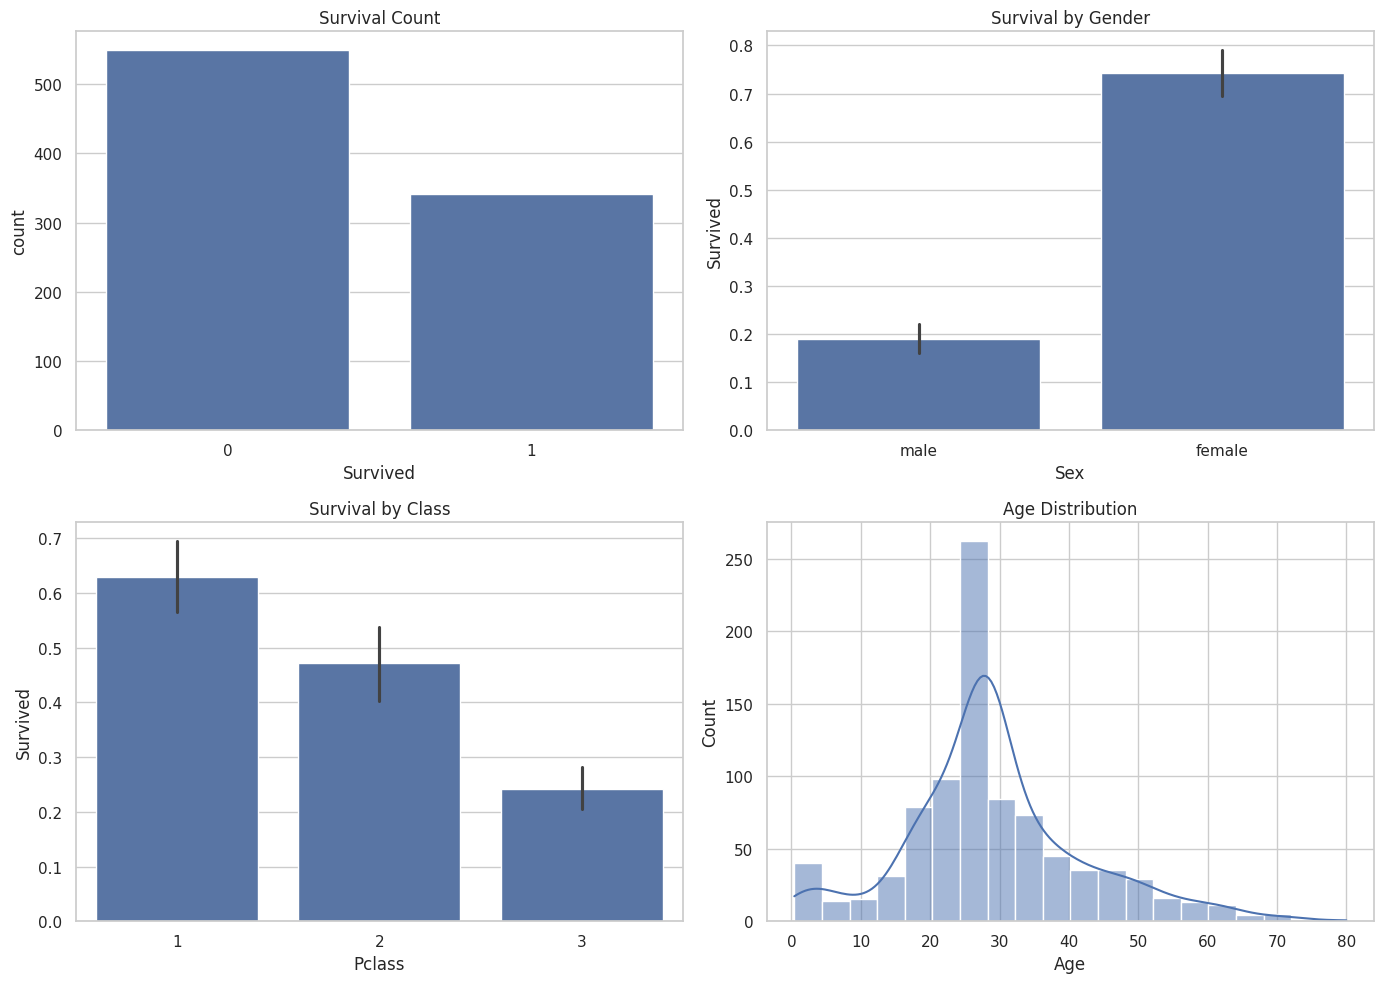

In [22]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival Count")

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival by Gender")

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1,0])
axes[1,0].set_title("Survival by Class")

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title("Age Distribution")

plt.tight_layout()
plt.show()

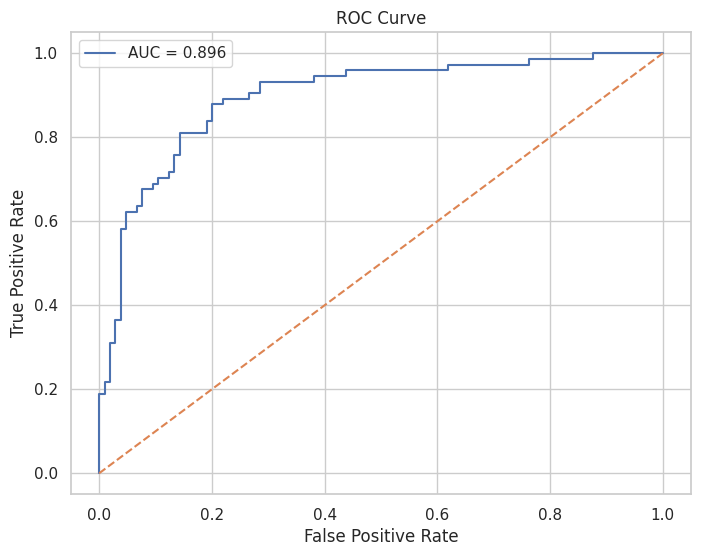

AUC Score: 0.8956241956241956


In [23]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

Business Insights

• Women had the highest survival probability.
• First-class passengers had significantly better survival chances.
• Higher ticket fares were associated with higher survival.
• Age had moderate influence on survival outcomes.
• Family size impacted survival, suggesting social group dynamics during evacuation.
• Machine Learning successfully identified survival patterns with strong predictive performance.

In [24]:
!pip install shap

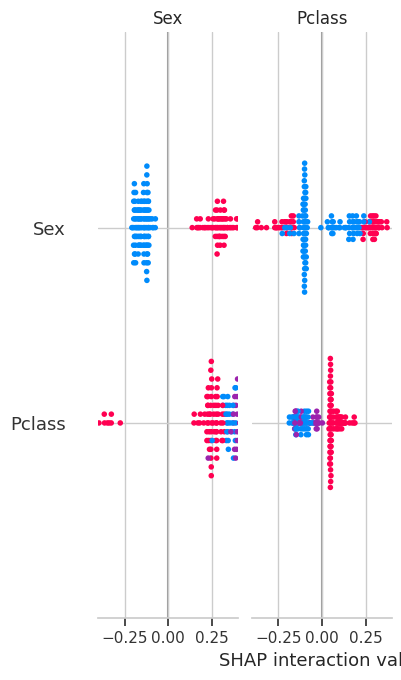

In [25]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


In [27]:
sample = pd.DataFrame({
    "Pclass":[1],
    "Sex":[1],      # Female
    "Age":[25],
    "Fare":[80],
    "FamilySize":[2],
    "IsAlone":[0],
    "Embarked":[1]
})

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Predicted: Survived")
else:
    print("Predicted: Not Survived")

Predicted: Survived


In [28]:
print("""
PROJECT CONCLUSION

The Titanic dataset was analyzed using data cleaning,
exploratory data analysis, visualization,
machine learning, and explainable AI.

Key Findings:
• Gender was the strongest survival factor.
• First-class passengers had higher survival chances.
• Higher ticket fares correlated with survival.
• Family size influenced evacuation outcomes.
• Machine Learning achieved strong prediction accuracy.
• SHAP Explainable AI identified the most influential features.

This project demonstrates the complete Data Science pipeline:
Data Cleaning → EDA → Visualization →
Predictive Modeling → Explainable AI.
""")


PROJECT CONCLUSION

The Titanic dataset was analyzed using data cleaning,
exploratory data analysis, visualization,
machine learning, and explainable AI.

Key Findings:
• Gender was the strongest survival factor.
• First-class passengers had higher survival chances.
• Higher ticket fares correlated with survival.
• Family size influenced evacuation outcomes.
• Machine Learning achieved strong prediction accuracy.
• SHAP Explainable AI identified the most influential features.

This project demonstrates the complete Data Science pipeline:
Data Cleaning → EDA → Visualization →
Predictive Modeling → Explainable AI.



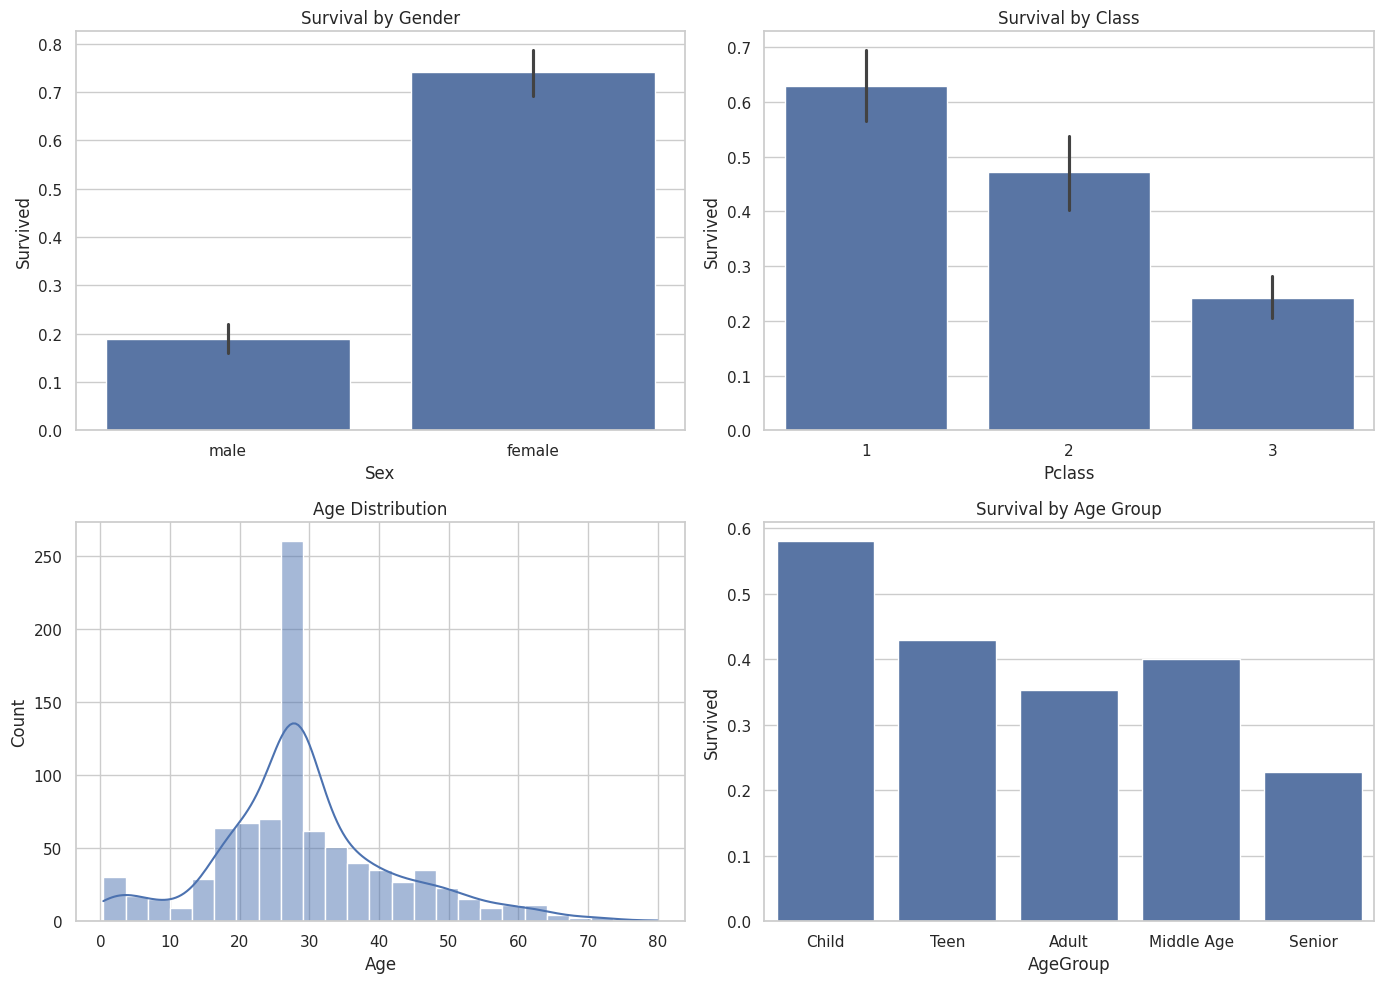

In [29]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival by Gender")

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival by Class")

sns.histplot(df['Age'], bins=25, kde=True, ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

sns.barplot(x='AgeGroup', y='Survived', data=age_survival, ax=axes[1,1])
axes[1,1].set_title("Survival by Age Group")

plt.tight_layout()
plt.show()

The Titanic dataset was analyzed using data preprocessing, exploratory data analysis, visualization techniques, machine learning, and Explainable AI.

The study revealed that gender was the most influential factor affecting survival. Female passengers had a significantly higher probability of survival than male passengers. Passenger class also played a major role, with first-class passengers experiencing substantially better survival outcomes than third-class passengers.

Age analysis showed that children had the highest survival rates, while senior passengers were the most vulnerable. Ticket fare and family size also contributed to survival chances.

A Random Forest Classifier was developed to predict passenger survival and achieved an accuracy of 81.01%, demonstrating strong predictive capability. Feature Importance and SHAP Explainable AI analysis confirmed that gender, fare, age, and passenger class were the most influential features in determining survival outcomes.

This project successfully demonstrated the complete Data Science workflow, including:

Data Cleaning
Exploratory Data Analysis
Data Visualization
Feature Engineering
Machine Learning Prediction
Explainable AI (SHAP)

The findings provide valuable insights into historical survival patterns and showcase the practical application of Data Science techniques for predictive analytics.

Future Improvements
Test multiple machine learning algorithms such as XGBoost, LightGBM, and CatBoost.
Perform hyperparameter optimization using GridSearchCV.
Build an interactive dashboard using Streamlit.
Deploy the model as a web application.
Use advanced Explainable AI techniques for deeper interpretation.